### Imports

In [ ]:
#!conda install -c conda-forge scikit-plot
!pip install scikit-plot
#if getting ImportError from scikiplot, downgrade scipy to 1.11.4 and restart session
!pip install scipy==1.11.4
import matplotlib.pyplot as plt

In [ ]:
# OR, PATH MANUALLY TO USE NUMPY INTERP RATHER THAN SCIPY INTERP
!vim /$WORK/$USER/conda/envs/ai1008/lib/python3.13/site-packages/scikitplot/metrics.py
!vim /$WORK/$USER/conda/envs/ai1008/lib/python3.13/site-packages/scikitplot/plotters.py

In [80]:
import scikitplot as skplt

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [ ]:
import plotly.express as px

### Data

In [3]:
#Loading the dataset
diabetes_data = pd.read_csv('diabetes.csv')

#Print the first 5 rows of the dataframe.
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
## observing the shape of the data
#768 rows, 9 columns, of which 1 is result: diabetes Y/N
diabetes_data.shape

(768, 9)

In [15]:
diabetes_data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


#### Observe trends in the data

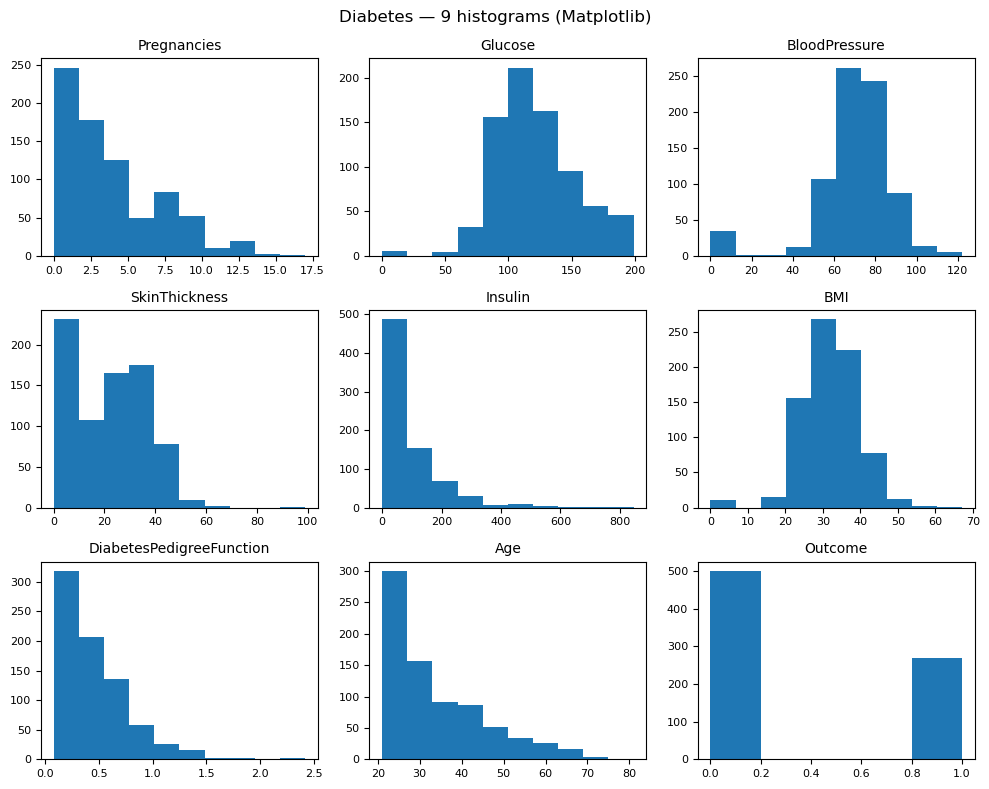

In [56]:
#observe trends in the data
# -----------------------------
# Matplotlib: 3×3 histogram grid
# -----------------------------
# Use a data-driven bin count for histogram (Freedman–Diaconis -- balances resolution/detail vs noise)
def _fd_bins(data: np.ndarray, *, min_bins: int = 4, max_bins: int = 10) -> int:
    # h = 2 * IQR(data) * numOfSamples^(-1/3) = FD bin width
    # IQR = 75th Quartile - 25th Quartile -- robust to outliers since ignores std
    # Theory: n^(-1/3) term comes from minimizing the asymptotic mean integrated squared error of the histogram as a density estimator.
    x = np.asarray(data)
    x = x[~np.isnan(x)] #remove all NaN values, by selecting only those elements which are False in isnan
    #if just 1 datapoint OR all values almost the same, return min_bins
    #x.size is same as len(x)
    if x.size < 2 or np.allclose(x.min(), x.max()):
        return min_bins
    #'*' is unpacking operator, unpacks the two outputs [75th percentile, 25th percentile] so they can be subtracted
    iqr = np.subtract(*np.percentile(x, [75, 25])) #equivalent to p.percentile(x, 75) - np.percentile(x, 25)
    iqr = max(iqr, 1e-12) #avoid zero or infinitesimal - cases where data almost all similar
    h = 2 * iqr * (x.size ** (-1/3) + 1e-9)
    h = max(h, 1e-12) #avoid zero
    # number of bins ≈ (max x - min x)/h
    numbins = int(np.ceil((x.max() - x.min()) / h))
    return int(np.clip(numbins, min_bins, max_bins)) #ensure result within the bounds

def gridplot_mlp(bufferdf: pd.DataFrame, buftitle: str = "3x3 Gridplot for dataframe") -> plt.Figure:
    cols = bufferdf.select_dtypes(include=[np.number]).columns[:].tolist() #get ALL 'number' columns names in list form
    fig, axes = plt.subplots(3, 3, figsize=(10, 8))
    axes = axes.ravel() #flattens axes array from 2D 3x3 to 1D array with 9 elements so we can iterate over them in a single loop instead of needing nested loop
    for ax, c in zip(axes, cols):
        x = bufferdf[c].dropna().values
        ax.hist(x, bins=_fd_bins(x))
        ax.set_title(c, fontsize=10)
        ax.tick_params(labelsize=8)

    fig.suptitle(buftitle, fontsize=12)
    fig.tight_layout()
    # plt.show()
    return fig
bufv = gridplot_mlp(diabetes_data, "Diabetes — 9 histograms (Matplotlib)")

In [ ]:
diabetes_data[cols].melt(var_name="Variable", value_name="Value")

In [16]:
# -----------------------------
# Plotly: 3×3 histogram grid
# -----------------------------
cols = diabetes_data.select_dtypes(include=[np.number]).columns[:].tolist() #get ALL 'number' columns names in list form
fig = make_subplots(rows=3, cols=3, subplot_titles=cols, horizontal_spacing=0.08, vertical_spacing=0.1)

for i, c in enumerate(cols, start=1): #enumerate cols with numbers starting from 1
    r = (i - 1) // 3 + 1
    k = (i - 1) % 3 + 1
    x = diabetes_data[c].dropna().values

    # Let Plotly choose bins auto, else can also use nbinsx
    hist = go.Histogram(
        x=x,
        nbinsx=None,
        autobinx=True,
        name=c,
        showlegend=False
    )
    fig.add_trace(hist, row=r, col=k)

fig.update_layout(
    title="Diabetes — 9 histograms (Plotly)",
    height=800, width=1000
)
fig.update_xaxes(title_text="value")
fig.update_yaxes(title_text="count")
display(fig)

In [25]:
# -----------------------------
# Plotly Express: FASTER 3×3 histogram grid (but less informative)
# -----------------------------
# Combine data into long-form for Plotly Express
df_long = diabetes_data[cols].melt(var_name="Variable", value_name="Value")

fig = px.histogram( #handles bins and subplot arrangement
    df_long,
    x="Value",
    facet_col="Variable", #ells Plotly Express to make a subplot for each variable
    facet_col_wrap=3,    # Arrange as 3 columns per row (automatically building 3x3 grid for 9 cols)
    title="Diabetes — 9 histograms (Plotly Express)"
    # width=280*3,   # About 280 px per subplot since this sets width for entire chart
    # height=240*3,  # About 240 px per subplot since this sets height for entire chart
)

fig.update_layout(
    showlegend=False,
    margin=dict(l=20, r=20, t=60, b=40)  # Reduce padding
)
fig.show()

#### Prepare data

In [4]:
# split data into dependent and independent
X = diabetes_data.drop("Outcome",axis = 1)
y = diabetes_data.Outcome

In [26]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [58]:
#importing train_test_split
from sklearn.model_selection import train_test_split
#split 66-33
#stratify is REALLY important for imbalanced datasets - ensures that the proportion of classes (labels in y) is preserved in both the training and test sets, so both have same percentage of each Y value as did the original data X
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1/3,random_state=42, stratify=y)

##### Visualise the splits
Y proportions are similar in both sets, constituency of other columns varies

In [29]:
X_train.shape

(512, 8)

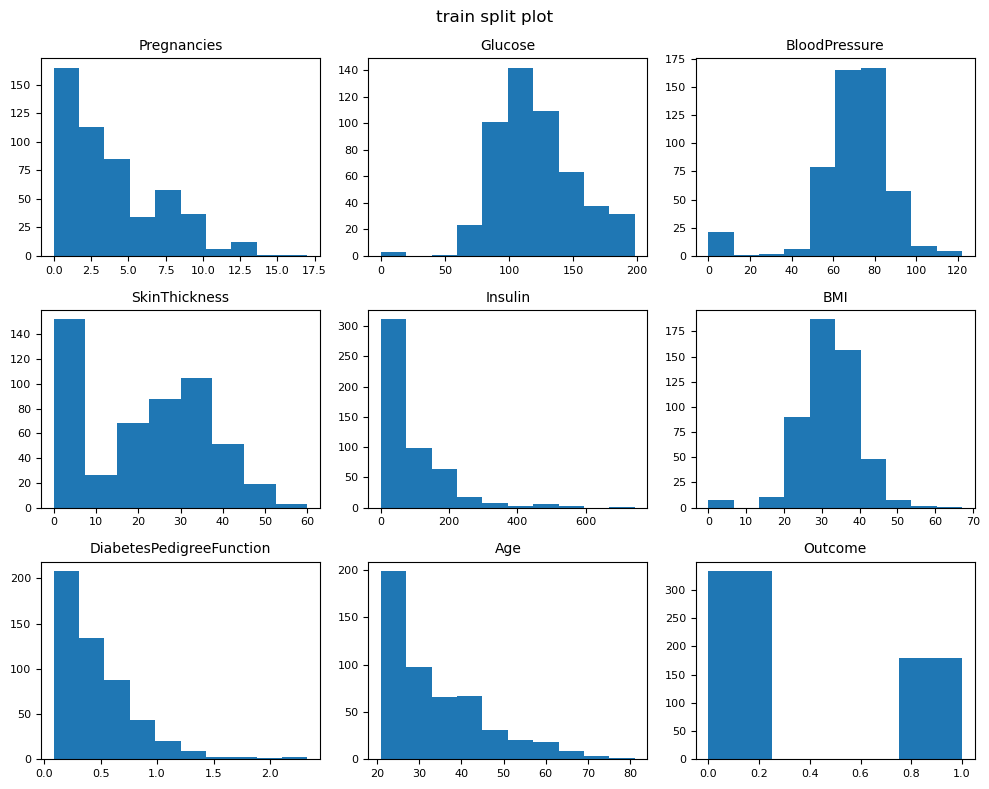

In [64]:
bufplots = []
bufplots.append(gridplot_mlp( pd.concat([X_train, y_train], axis=1), "train split plot" ))

In [35]:
X_test.shape

(256, 8)

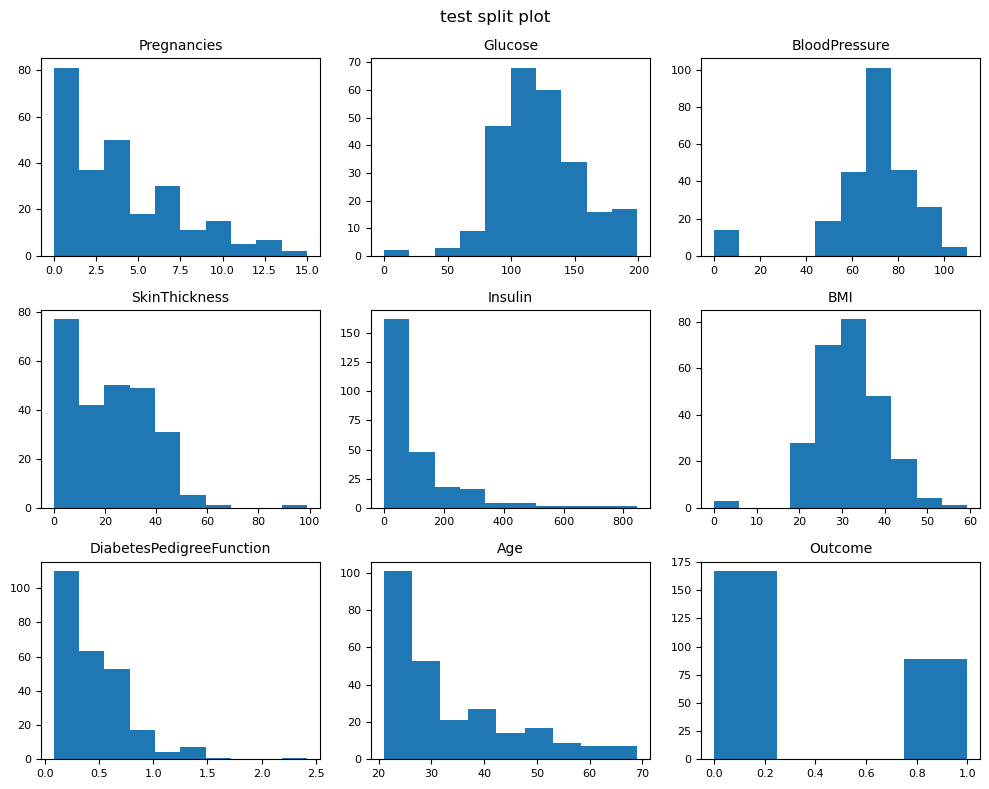

In [65]:
bufplots.append(gridplot_mlp( pd.concat([X_test, y_test], axis=1), "test split plot" ))

##### Standardize dependent features, visualise
each feature (column) will have a mean of 0 and a standard deviation of 1 after transformation.

In [66]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train) #computes the mean and standard deviation for each feature in the training set

#apply this scaling from train set to both the training and test sets
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

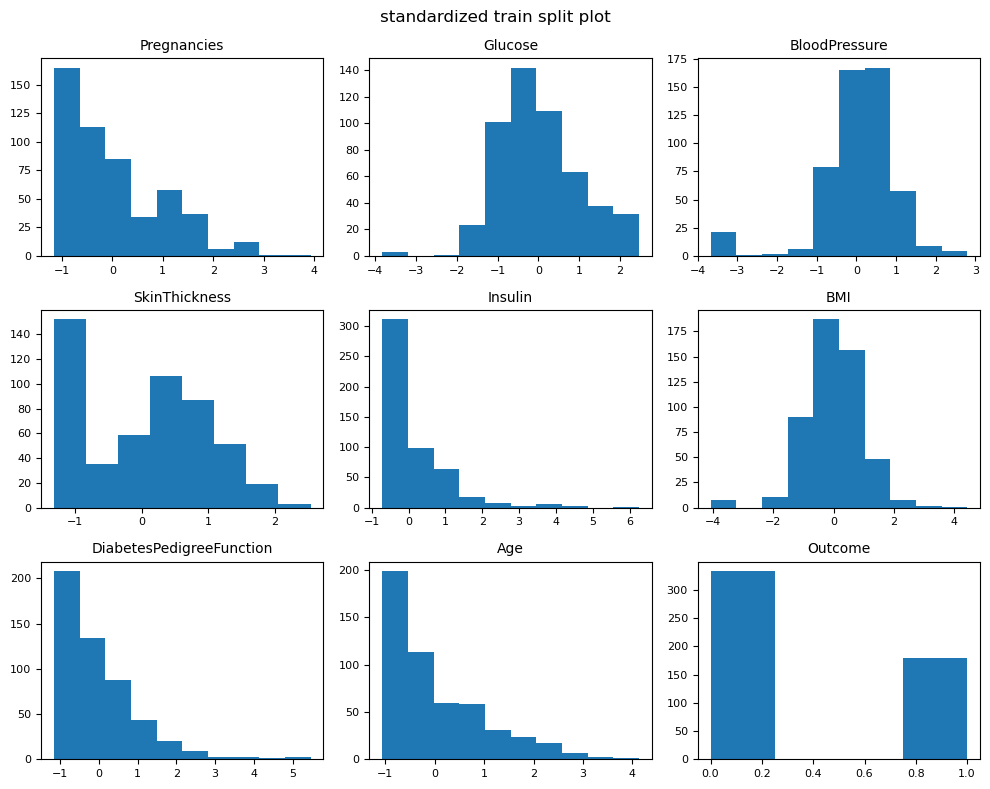

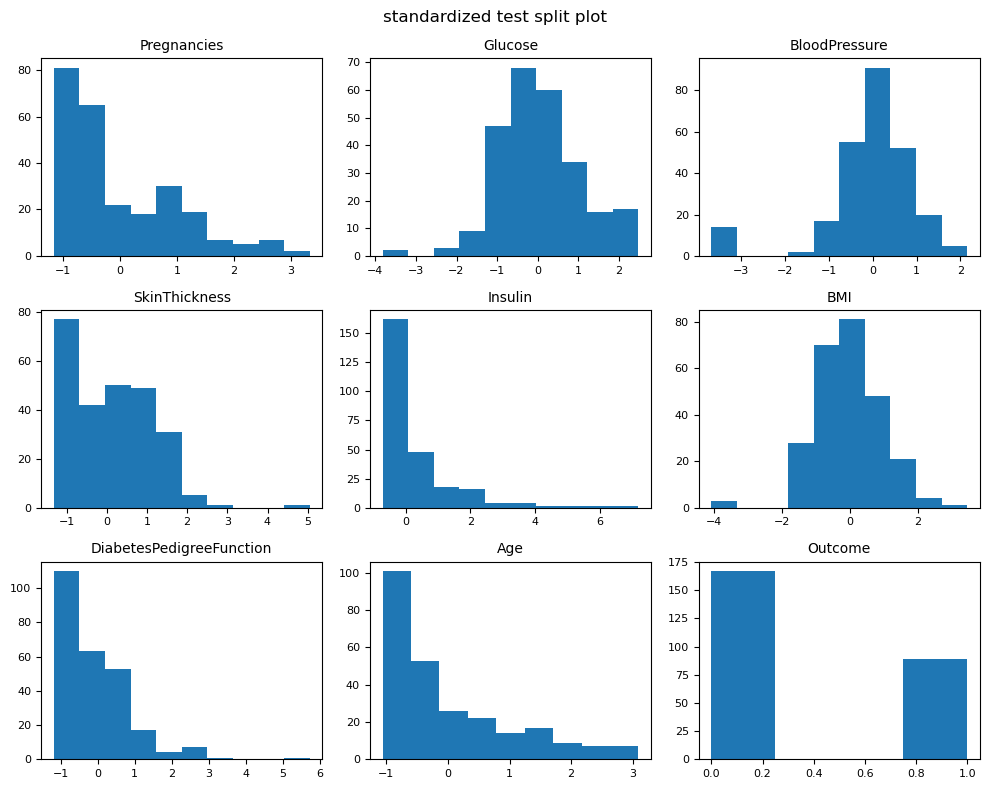

In [67]:
# clearly (comparing with above two plots respectively), the changes are minute but still useful
bufplots.append(gridplot_mlp( pd.concat([pd.DataFrame(X_train, columns=diabetes_data.columns[:8]), y_train], axis=1), "standardized train split plot" ))
bufplots.append(gridplot_mlp( pd.concat([pd.DataFrame(X_test, columns=diabetes_data.columns[:8]), y_test], axis=1), "standardized test split plot" ))

In [70]:
bufplots

[<Figure size 1000x800 with 9 Axes>,
 <Figure size 1000x800 with 9 Axes>,
 <Figure size 1000x800 with 9 Axes>,
 <Figure size 1000x800 with 9 Axes>]

# LOGISTIC REGRESSION

In [71]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(C=0.01).fit(X_train, y_train)
print("Training set score: {:.3f}".format(logreg.score(X_train, y_train)))
print("Test set score: {:.3f}".format(logreg.score(X_test, y_test)))

Training set score: 0.771
Test set score: 0.727


In [72]:
logreg.intercept_.T

array([-0.69621296])

In [73]:
logreg.coef_.T

array([[ 0.21042559],
       [ 0.47107887],
       [-0.02092277],
       [-0.00745565],
       [ 0.08928276],
       [ 0.29787811],
       [ 0.11139586],
       [ 0.13298418]])

### Confusion Matrix

In [74]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = logreg.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[150  17]
 [ 53  36]]
              precision    recall  f1-score   support

           0       0.74      0.90      0.81       167
           1       0.68      0.40      0.51        89

    accuracy                           0.73       256
   macro avg       0.71      0.65      0.66       256
weighted avg       0.72      0.73      0.71       256



### ROC

Accuracy= 0.76171875


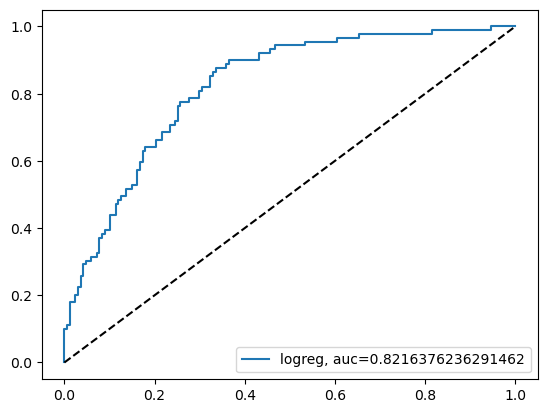

In [119]:
from sklearn import metrics


print("Accuracy=", metrics.accuracy_score(y_test, y_pred))

y_pred_proba = logreg.predict_proba(X_test)[::,1]
fpr_logreg, tpr_logreg, _ = metrics.roc_curve(y_test, y_pred_proba)
auc_logreg = metrics.roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr_logreg, tpr_logreg, label="logreg, auc=" + str(auc_logreg))
plt.plot([0,1],[0,1],'k--')
plt.legend(loc=4)
plt.show()

### Gains / Lift Chart

In [76]:
y_pred_probas = logreg.predict_proba(X_test)

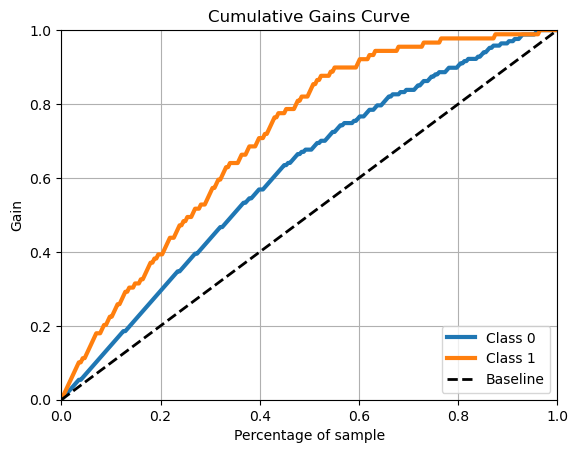

In [81]:
skplt.metrics.plot_cumulative_gain(y_test, y_pred_probas)
plt.show()

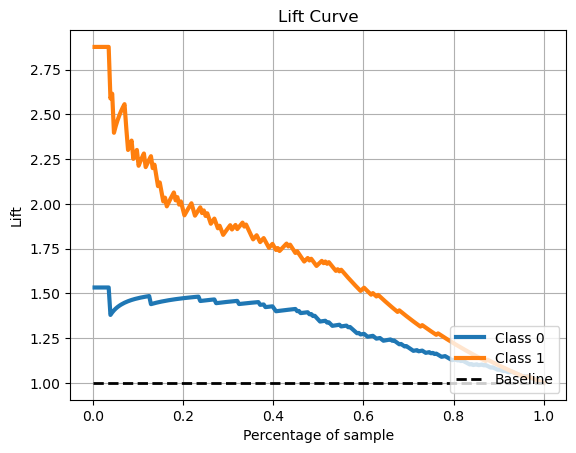

In [82]:
skplt.metrics.plot_lift_curve(y_test, y_pred_probas)
plt.show()

# K-NN

In [107]:
from sklearn.neighbors import KNeighborsClassifier

test_scores = []
train_scores = []

for i in range(1,15):

    knn = KNeighborsClassifier(i)
    knn.fit(X_train,y_train)

    train_scores.append(knn.score(X_train,y_train))
    test_scores.append(knn.score(X_test,y_test))

In [108]:
## score that comes from testing on the same datapoints that were used for training
max_train_score = max(train_scores)
train_scores_ind = [i for i, v in enumerate(train_scores) if v == max_train_score]
print('Max train score {} % and k = {}'.format(max_train_score*100,list(map(lambda x: x+1, train_scores_ind))))

Max train score 100.0 % and k = [1]


In [109]:
## score that comes from testing on the datapoints that were split in the beginning to be used for testing solely
max_test_score = max(test_scores)
test_scores_ind = [i for i, v in enumerate(test_scores) if v == max_test_score]
print('Max test score {} % and k = {}'.format(max_test_score*100,list(map(lambda x: x+1, test_scores_ind))))

Max test score 76.171875 % and k = [9, 10, 11]


### K-NN Result Visualisation

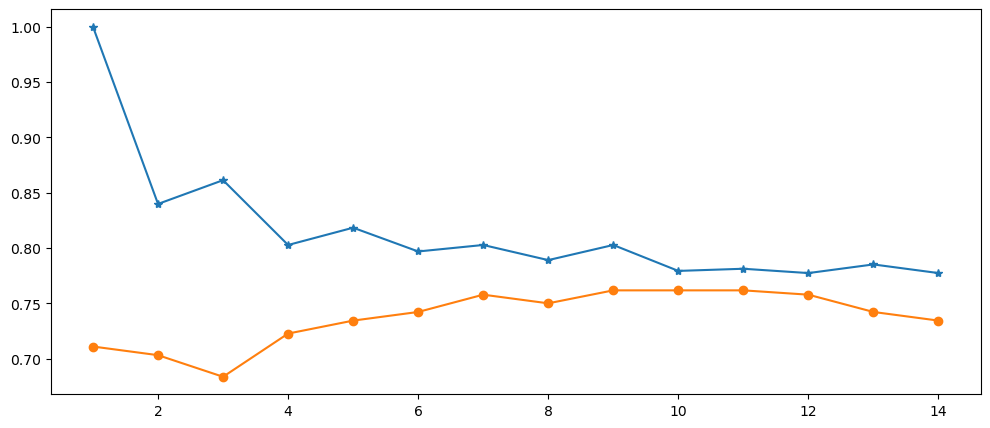

In [86]:
plt.figure(figsize=(12,5))
plt.plot(range(1,15),train_scores,marker='*',label='Train Score')
plt.plot(range(1,15),test_scores,marker='o',label='Test Score')

#### The best result is captured at k = 11 hence 11 is used for the final model

In [110]:
#Setup a knn classifier with k neighbors
knn = KNeighborsClassifier(11)

knn.fit(X_train,y_train)
knn.score(X_test,y_test)

0.76171875

## Model Performance Analysis

In [111]:
#import confusion_matrix
from sklearn.metrics import confusion_matrix
#let us get the predictions using the classifier we had fit above
y_pred = knn.predict(X_test)
#confusion_matrix(y_test,y_pred)
pd.crosstab(y_test, y_pred, rownames=['True'], colnames=['Predicted'], margins=True)

Predicted,0,1,All
True,,,
0,145,22,167
1,39,50,89
All,184,72,256


In [112]:
#import classification_report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.87      0.83       167
           1       0.69      0.56      0.62        89

    accuracy                           0.76       256
   macro avg       0.74      0.72      0.72       256
weighted avg       0.76      0.76      0.75       256



In [113]:
from sklearn.metrics import roc_curve
y_pred_proba = knn.predict_proba(X_test)[:,1]
fpr_knn, tpr_knn, thresholds = roc_curve(y_test, y_pred_proba)

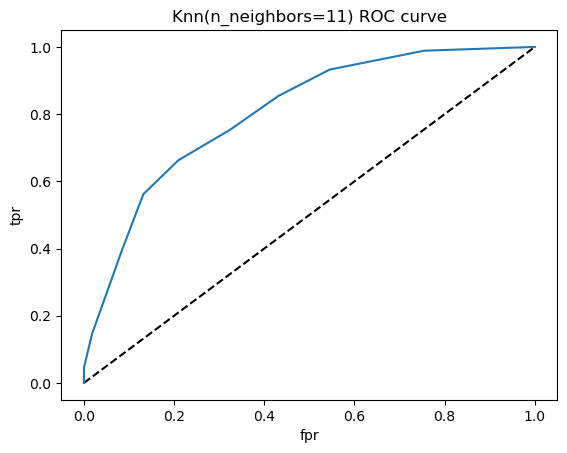

In [114]:
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr_knn, tpr_knn, label='Knn')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('Knn(n_neighbors=11) ROC curve')
plt.show()

In [92]:
#Area under ROC curve
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,y_pred_proba)
# auc_knn = roc_auc_score(y_test, y_pred_proba_knn)

0.8042454417008679

In [120]:
auc_knn=0.8042454417008679

In [93]:
#import GridSearchCV
from sklearn.model_selection import GridSearchCV
#In case of classifier like knn the parameter to be tuned is n_neighbors
param_grid = {'n_neighbors':np.arange(1,50)}
knn = KNeighborsClassifier()
knn_cv= GridSearchCV(knn,param_grid,cv=5)
knn_cv.fit(X_train,y_train)

print("Best Score:" + str(knn_cv.best_score_))
print("Best Parameters: " + str(knn_cv.best_params_))

Best Score:0.7772701313535123
Best Parameters: {'n_neighbors': np.int64(19)}


# Naiive Bayes

In [94]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix

In [95]:
# Initiating the Gaussian Classifier
mod = GaussianNB()

In a Jupyter environment, please rerun this cell to show the HTML representation or trust the notebook.
On GitHub, the HTML representation is unable to render, please try loading this page with nbviewer.org.


GaussianNB
?Documentation for GaussianNBiFitted

GaussianNB()

In [96]:
# Training your model
mod.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [97]:
GaussianNB()

,priors,None
,var_smoothing,1e-09


In [98]:
# Predicting Outcome
predicted = mod.predict(X_test)

In [99]:
mod.score(X_test,y_test)

0.73828125

In [100]:
# Confusion Matrix
y_pred = mod.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[132  35]
 [ 32  57]]
              precision    recall  f1-score   support

           0       0.80      0.79      0.80       167
           1       0.62      0.64      0.63        89

    accuracy                           0.74       256
   macro avg       0.71      0.72      0.71       256
weighted avg       0.74      0.74      0.74       256



### ROC

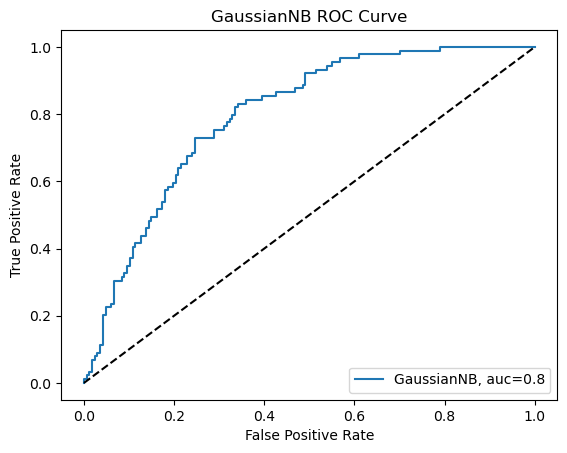

In [118]:
from sklearn.metrics import roc_curve, roc_auc_score

# Fit and predict probabilities
mod = GaussianNB()
mod.fit(X_train, y_train)
y_pred_proba = mod.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_pred_proba)
auc_nb = roc_auc_score(y_test, y_pred_proba)

plt.plot(fpr_nb, tpr_nb, label="GaussianNB, auc=" + str(round(auc_nb, 2)))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('GaussianNB ROC Curve')
plt.legend(loc=4)
plt.show()

In [47]:
# You can compare the performance of multiple models in one ROC chart. Write your own codes in the cells below.

##  Combined ROC Curve for All Three Models

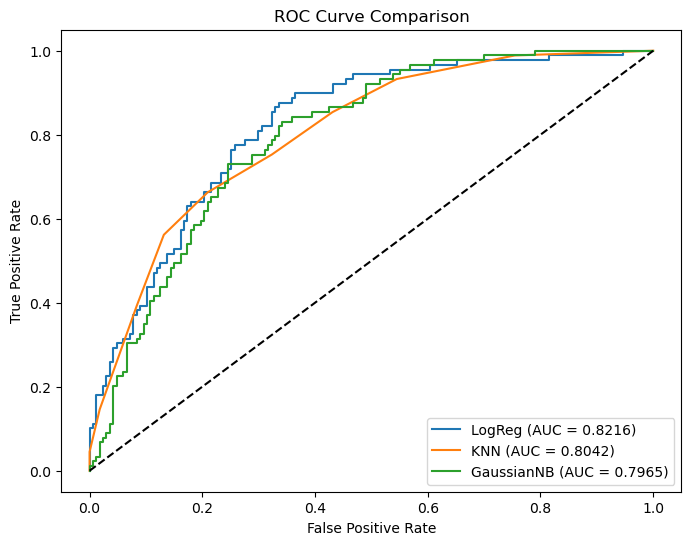

In [122]:
# Plot all ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f"LogReg (AUC = {auc_logreg:.4f})")         # Logistic Regression
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.4f})") # KNN
plt.plot(fpr_nb, tpr_nb, label=f"GaussianNB (AUC = {auc_nb:.4f})") # GaussianNB
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()


### CONCLUSION
Although all three models perform fairly well and they are almost the same distance from the top left corner, **LogReg has overall performed best**, with the greated AUC measure.

It’s important to note that “best” here means it had the highest overall discriminative power (best overall ability to distinguish between the classes among the three models tested; as measured by AUC), not necessarily that it is perfect or optimal for all use cases e.g. IF our application values minimizing false positives or false negatives more, we can look at specific regions of the ROC curve or other metrics


#### Why ROC?
ROC curves are especially useful for imbalanced datasets, as they are not affected by class distribution, unlike accuracy (since accuracy measures proportion of correct predictions out of total, it doesn't consider # of samples that belong to each class).